In [96]:
%load_ext autoreload
%autoreload 2

from pyvtna.vtna import VTNA, order_search, order_opt, normalize_time
from pyvtna.testing import simulate_reaction_trace
from scipy.optimize import minimize
from pyvtna.metrics import RMSD
import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Generating Dummy Data

For testing purposes, let's generate some fake data for the reaction:

$$2NO + O_2 \longrightarrow 2NO_2,  Rate=k[NO]^2[O_2]$$

We don't care about absolute rates, so we will just set k = 1

In [2]:
time = np.linspace(0, 1600, 1600)
k = 0.001

# order reactants as [NO, O2]
reac_st = [2., 1.]
reac_orders = [2, 1]
reac_coefs = [2., 1.]
prod_st = [0.]
prod_coefs = [2]
noise = 0.05

[NO, O2], [NO2] = simulate_reaction_trace(time, reac_st, reac_orders, reac_coefs, 
                                           prod_st, prod_coefs, k=k, noise=noise)

## Differing Starting Concentrations
Now let's simulate a second run of the reaction, but with the starting concentration of NO doubled, as if running a series of rate experiments

In [3]:
time2 = np.linspace(0, 1400, 1400)
reac_st = [3., 1.]
[NO_b, O2_b], [NO2_b] = simulate_reaction_trace(time2, reac_st, reac_orders, reac_coefs, 
                                                prod_st, prod_coefs, k=k, noise=noise)

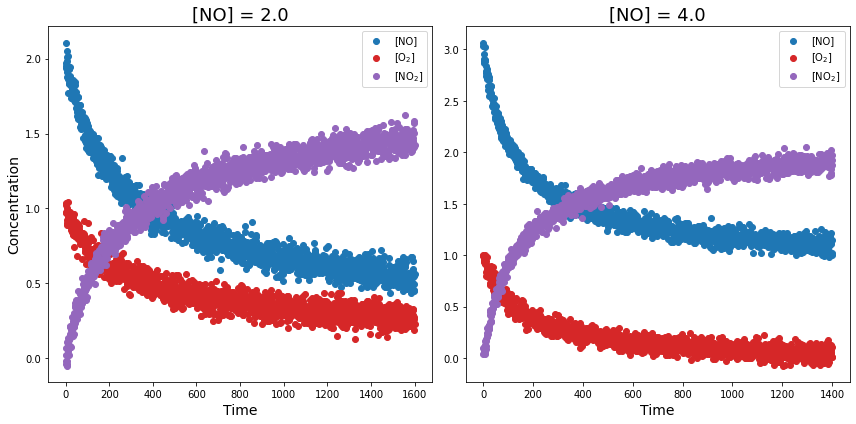

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.scatter(time, NO, c='tab:blue', label="[NO]")
ax1.scatter(time, O2, c='tab:red', label="[O$_2$]")
ax1.scatter(time, NO2, c='tab:purple', label="[NO$_2$]")
ax1.legend()
ax1.set_xlabel('Time', fontsize=14)
ax1.set_ylabel('Concentration', fontsize=14)
ax1.set_title('[NO] = 2.0', fontsize=18)

ax2.scatter(time2, NO_b, c='tab:blue', label="[NO]")
ax2.scatter(time2, O2_b, c='tab:red', label="[O$_2$]")
ax2.scatter(time2, NO2_b, c='tab:purple', label="[NO$_2$]")
ax2.legend()
ax2.set_xlabel('Time', fontsize=14)
ax2.set_title('[NO] = 4.0', fontsize=18)

plt.tight_layout()
plt.show()

## Try the Auto-Fit

Best fit achieved for an order of 1.99.


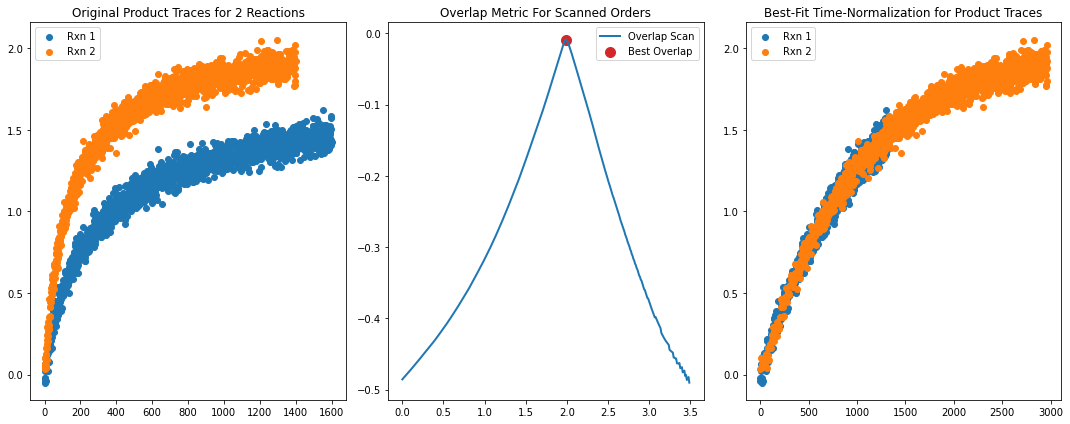

In [5]:
besto, rs = order_search(time, time2, NO2, NO2_b, NO, NO_b, o_range=(0,3.5), o_step=0.01, 
               to_smooth=True, win1=None, win2=None, window_type='blackman', plot=True, figsize=(15,6))

## Now for the Second Reactant

Using autofit, we see that the order for NO is approximately 2. Let's normalize the time with this, then fit for the order of the second reactant, O$_2$.

In [6]:
t_norm_NO = normalize_time(time, NO, 2)
t_norm_NO_b = normalize_time(time2, NO_b, 2)

To fit for the remaining reactant order, we can do just a first order search to find the order that normalizes the trace to a straight line. This is handled by the `VTNA` class. We do it for both reactions. They should both produce optimal orders of 1.

In [7]:
VTNA_O2 = VTNA(t_norm_NO, NO2, O2)
VTNA_O2.smooth_data(win=30, win_type='blackman')
VTNA_O2.optimize(np.array([0]), 
                     method='nelder-mead', 
                     options={'xatol': 1e-2, 'fatol': 1e-5, 'disp': True})

Optimization terminated successfully.
         Current function value: -0.998521
         Iterations: 18
         Function evaluations: 36


array([1.01575])

In [8]:
VTNA_O2_b = VTNA(t_norm_NO_b, NO2_b, O2_b)
VTNA_O2_b.smooth_data(win=20, win_type='blackman')
VTNA_O2_b.optimize(np.array([0]), 
                     method='nelder-mead', 
                     options={'xatol': 1e-2, 'fatol': 1e-5, 'disp': True})

Optimization terminated successfully.
         Current function value: -0.998513
         Iterations: 18
         Function evaluations: 36


array([1.00775])

In [9]:
t_norm_NO_O2 = normalize_time(t_norm_NO, O2, 1)
t_norm_NO_O2_b = normalize_time(t_norm_NO_b, O2_b, 1)

As hoped for, the order of [O$_2$] is found to be $\approx$ 1 in both reactions. Now, we can plot the steps to reaction normalization for each reaction.

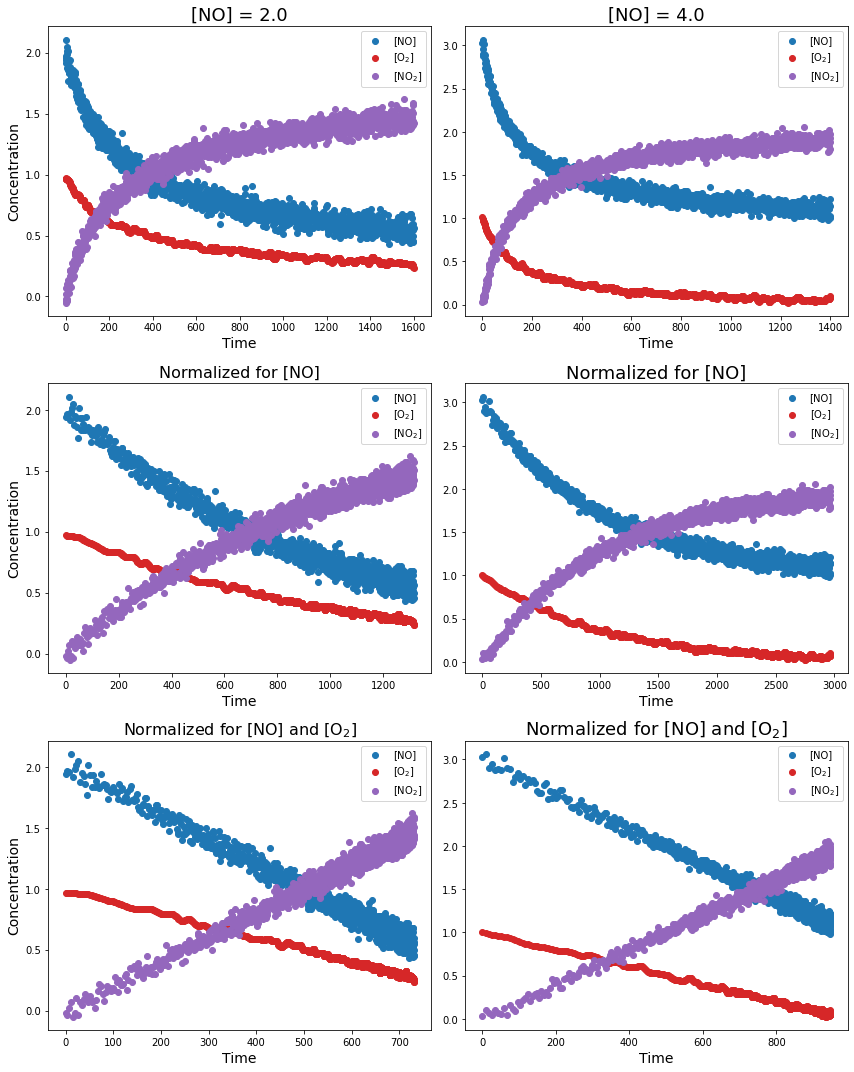

In [10]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(12, 15))

ax1.scatter(time, NO, c='tab:blue', label="[NO]")
ax1.scatter(time, O2, c='tab:red', label="[O$_2$]")
ax1.scatter(time, NO2, c='tab:purple', label="[NO$_2$]")
ax1.legend()
ax1.set_xlabel('Time', fontsize=14)
ax1.set_ylabel('Concentration', fontsize=14)
ax1.set_title('[NO] = 2.0', fontsize=18)

ax2.scatter(time2, NO_b, c='tab:blue', label="[NO]")
ax2.scatter(time2, O2_b, c='tab:red', label="[O$_2$]")
ax2.scatter(time2, NO2_b, c='tab:purple', label="[NO$_2$]")
ax2.legend()
ax2.set_xlabel('Time', fontsize=14)
ax2.set_title('[NO] = 4.0', fontsize=18)

# First Normalization Step -- NO order 2
ax3.scatter(t_norm_NO, NO, c='tab:blue', label="[NO]")
ax3.scatter(t_norm_NO, O2, c='tab:red', label="[O$_2$]")
ax3.scatter(t_norm_NO, NO2, c='tab:purple', label="[NO$_2$]")
ax3.legend()
ax3.set_xlabel('Time', fontsize=14)
ax3.set_ylabel('Concentration', fontsize=14)
ax3.set_title('Normalized for [NO]', fontsize=16)

ax4.scatter(t_norm_NO_b, NO_b, c='tab:blue', label="[NO]")
ax4.scatter(t_norm_NO_b, O2_b, c='tab:red', label="[O$_2$]")
ax4.scatter(t_norm_NO_b, NO2_b, c='tab:purple', label="[NO$_2$]")
ax4.legend()
ax4.set_xlabel('Time', fontsize=14)
ax4.set_title('Normalized for [NO]', fontsize=18)

# Second Normalization Step -- O2 order 1
ax5.scatter(t_norm_NO_O2, NO, c='tab:blue', label="[NO]")
ax5.scatter(t_norm_NO_O2, O2, c='tab:red', label="[O$_2$]")
ax5.scatter(t_norm_NO_O2, NO2, c='tab:purple', label="[NO$_2$]")
ax5.legend()
ax5.set_xlabel('Time', fontsize=14)
ax5.set_ylabel('Concentration', fontsize=14)
ax5.set_title('Normalized for [NO] and [O$_2$]', fontsize=16)

ax6.scatter(t_norm_NO_O2_b, NO_b, c='tab:blue', label="[NO]")
ax6.scatter(t_norm_NO_O2_b, O2_b, c='tab:red', label="[O$_2$]")
ax6.scatter(t_norm_NO_O2_b, NO2_b, c='tab:purple', label="[NO$_2$]")
ax6.legend()
ax6.set_xlabel('Time', fontsize=14)
ax6.set_title('Normalized for [NO] and [O$_2$]', fontsize=18)

plt.tight_layout()
plt.show()

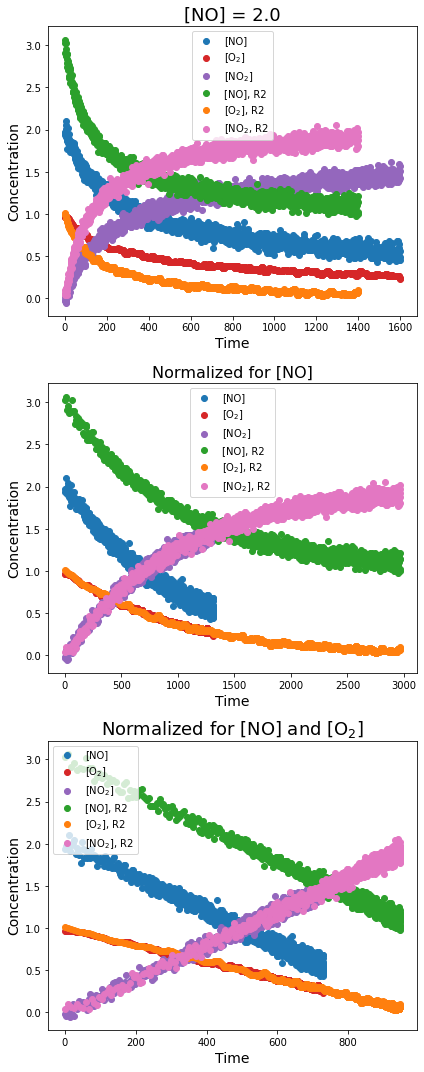

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6, 15))

ax1.scatter(time, NO, c='tab:blue', label="[NO]")
ax1.scatter(time, O2, c='tab:red', label="[O$_2$]")
ax1.scatter(time, NO2, c='tab:purple', label="[NO$_2$]")
ax1.set_xlabel('Time', fontsize=14)
ax1.set_ylabel('Concentration', fontsize=14)
ax1.set_title('[NO] = 2.0', fontsize=18)

ax1.scatter(time2, NO_b, c='tab:green', label="[NO], R2")
ax1.scatter(time2, O2_b, c='tab:orange', label="[O$_2$], R2")
ax1.scatter(time2, NO2_b, c='tab:pink', label="[NO$_2$, R2")
ax1.legend()
ax1.set_xlabel('Time', fontsize=14)

# First Normalization Step -- NO order 2
ax2.scatter(t_norm_NO, NO, c='tab:blue', label="[NO]")
ax2.scatter(t_norm_NO, O2, c='tab:red', label="[O$_2$]")
ax2.scatter(t_norm_NO, NO2, c='tab:purple', label="[NO$_2$]")
ax2.set_xlabel('Time', fontsize=14)
ax2.set_ylabel('Concentration', fontsize=14)
ax2.set_title('Normalized for [NO]', fontsize=16)

ax2.scatter(t_norm_NO_b, NO_b, c='tab:green', label="[NO], R2")
ax2.scatter(t_norm_NO_b, O2_b, c='tab:orange', label="[O$_2$], R2")
ax2.scatter(t_norm_NO_b, NO2_b, c='tab:pink', label="[NO$_2$], R2")
ax2.set_xlabel('Time', fontsize=14)
ax2.legend()

# Second Normalization Step -- O2 order 1
ax3.scatter(t_norm_NO_O2, NO, c='tab:blue', label="[NO]")
ax3.scatter(t_norm_NO_O2, O2, c='tab:red', label="[O$_2$]")
ax3.scatter(t_norm_NO_O2, NO2, c='tab:purple', label="[NO$_2$]")
ax3.set_xlabel('Time', fontsize=14)
ax3.set_ylabel('Concentration', fontsize=14)
ax3.set_title('Normalized for [NO] and [O$_2$]', fontsize=16)

ax3.scatter(t_norm_NO_O2_b, NO_b, c='tab:green', label="[NO], R2")
ax3.scatter(t_norm_NO_O2_b, O2_b, c='tab:orange', label="[O$_2$], R2")
ax3.scatter(t_norm_NO_O2_b, NO2_b, c='tab:pink', label="[NO$_2$], R2")
ax3.set_xlabel('Time', fontsize=14)
ax3.set_title('Normalized for [NO] and [O$_2$]', fontsize=18)
ax3.legend()

plt.tight_layout()
plt.show()

# Read in Reaction Data from Excel File

In [12]:
from pyvtna.readers import ExcelReader

In [13]:
hydroamination = ExcelReader("sampledata/Hydroamination-Kinetics-Catalyst-Order.xlsx")
cat_concs = [0.1, 0.118, 0.138, 0.16, 0.245, 0.29, 0.29, 0.33]

# Normalize time with known catalyst order=1
for i, rxn in enumerate(hydroamination.reaction_traces):
    rxn['t_norm'] = normalize_time(rxn['t'].values, cat_concs[i], 1)

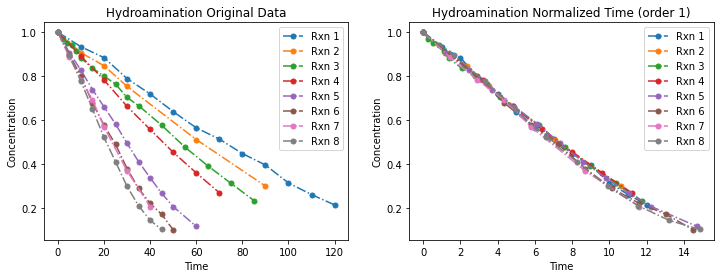

In [51]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for i, rxn in enumerate(hydroamination.reaction_traces):
    ax1.plot(rxn['t'], rxn[hydroamination.reactant_names[0]], '-.', marker='o', ms=5, label=f'Rxn {i+1}')
    ax2.plot(rxn['t_norm'], rxn[hydroamination.reactant_names[0]], '-.', marker='o', ms=5, label=f'Rxn {i+1}')
for ax in [ax1, ax2]:
    ax.set_xlabel('Time')
    ax.set_ylabel('Concentration')
    ax.legend()
ax1.set_title('Hydroamination Original Data')
ax2.set_title('Hydroamination Normalized Time (order 1)')
plt.show()

## Now try the Auto-fit

Use the `order_opt` function with all possible pairs of reaction traces. Average to get the optimal order.

In [15]:
import itertools

In [48]:
%%time
orders = []
for combo in itertools.combinations(range(len(hydroamination.reaction_traces)), 2):
    t1 = hydroamination.reaction_traces[combo[0]]['t'].values
    r1 = hydroamination.reaction_traces[combo[0]][hydroamination.reactant_names[0]].values
    t2 = hydroamination.reaction_traces[combo[1]]['t'].values
    r2 = hydroamination.reaction_traces[combo[1]][hydroamination.reactant_names[0]].values
    
    c1 = cat_concs[combo[0]]
    c2 = cat_concs[combo[1]]
    
    # scipy optimization. time ~194ms walltime for all iterations combined
    result, _ = order_opt(t1, t2, r1, r2, c1, c2, o_range=(0,2.5), method='Nelder-Mead', metric='RMSD', 
                          to_smooth=False, win1=None, win2=None, window_type='blackman', plot=False)
    orders.append(result.x[0])
    
    # slower grid search method. time ~1.25 s walltime for all iterations combined (~ 6.4 times slower)
#     besto, rs = order_search(t1, t2, r1, r2, c1, c2, o_range=(0,2.5), o_step=0.01, metric='RMSD', 
#                              to_smooth=False, win1=None, win2=None, window_type='blackman', plot=False, figsize=(15, 4))
#     orders.append(besto)
order = sum(orders) / len(orders)

CPU times: user 193 ms, sys: 8.9 ms, total: 202 ms
Wall time: 196 ms


In [49]:
order

1.0524771554129464

## Simulate Catalyzed Reaction

To simulate a catalyzed reaction, we can use the same function `simulate_reaction_trace` as before. The trick is to simply set the coefficient of the catalyst species to 0, while giving it a reaction order just like any other species. This will mean that the concentration appears in the rate law but not in the balanced chemical reaction, thereby enforcing a constant concentration throughout the reaction trace.

Catalyst poisoning can also be introduced by simply subtracting some set concentration of catalyst from the starting concentration and passing this diminished value to the `simulate_reaction_trace` function. Thus, the nominal catalyst concentration is slightly higher than the concentration actually available for chemical reaction.

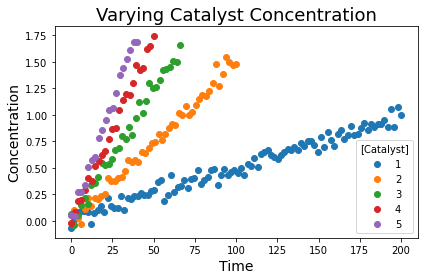

In [262]:
# time = np.linspace(0, 200, 2000)
k = 0.01

# order reactants as [NO, O2]
reac_st = [2., 2., 1.]
reac_orders = [0., 0., 1.]
reac_coefs = [1., 1., 0.]
prod_st = [0.]
prod_coefs = [1.]
noise = 0.05
poisoning = 0.5

fig, ax1 = plt.subplots(1, 1, figsize=(6, 4))

rxn_traces = {}
for cat_conc in [1, 2, 3, 4, 5]:
    reac_st[-1] = cat_conc - poisoning
    
    time = np.linspace(0, 200//cat_conc, 100//cat_conc)
    
    [r1, r2, c1], [p1] = simulate_reaction_trace(time, reac_st, reac_orders, reac_coefs, 
                                                 prod_st, prod_coefs, k=k, noise=noise)
    rxn_traces[cat_conc] = {}
    rxn_traces[cat_conc]['t'] = time
    rxn_traces[cat_conc]['r1'] = r1
    rxn_traces[cat_conc]['r2'] = r2
    rxn_traces[cat_conc]['c1'] = c1
    rxn_traces[cat_conc]['p1'] = p1
    
    ax1.scatter(time, p1, label=f"{cat_conc}")

ax1.set_xlabel('Time', fontsize=14)
ax1.set_ylabel('Concentration', fontsize=14)
ax1.set_title('Varying Catalyst Concentration', fontsize=18)
ax1.legend(title='[Catalyst]')
plt.tight_layout()
plt.show()

In [263]:
orders = []
cat_concs = list(rxn_traces.keys())

for combo in itertools.combinations(range(len(cat_concs)), 2):
    t1 = rxn_traces[cat_concs[combo[0]]]['t']
    p1 = rxn_traces[cat_concs[combo[0]]]['p1']
    t2 = rxn_traces[cat_concs[combo[1]]]['t']
    p2 = rxn_traces[cat_concs[combo[1]]]['p1']
    
    c1 = float(cat_concs[combo[0]])
    c2 = float(cat_concs[combo[1]])
    
    # scipy optimization. time ~194ms walltime for all iterations combined
    result, _ = order_opt(t1, t2, p1, p2, c1, c2, o_range=(0,2.5), method='Nelder-Mead', metric='RMSD', 
                          to_smooth=False, win1=None, win2=None, window_type='blackman', plot=False)
    orders.append(result.x[0])
    
    # slower grid search method. time ~1.25 s walltime for all iterations combined (~ 6.4 times slower)
#     besto, rs = order_search(t1, t2, p1, p2, c1, c2, o_range=(0,2.5), o_step=0.01, metric='RMSD', 
#                              to_smooth=False, win1=None, win2=None, window_type='blackman', plot=False, figsize=(15, 4))
#     orders.append(besto)
order = sum(orders) / len(orders)

In [264]:
order

1.32249755859375

## Fitting Poisoning

There are two options for fitting the catalyst poisoning in such a reaction.

1. Set the order to some value, and then maximize the reaction trace overlap by varying the assumed poison value
    - A 1D optimization
2. Maximize the reaction trace overlap over both the order and the poisoning.
    - A 2D optimization
    
Let's try option 1 first. The order found above is approximately 1. Let's assume that the reaction is in fact first order in the catalyst. Then we search for the poisoning value (let's limit it to be between zero and the lowest catalyst concentration so we do not end up with negative values) that maximizes the reaction trace overlap, given an order of 1.

For now we neglect any smoothing and just test out the algorithm in its simplest state.

In [265]:
from scipy.interpolate import interp1d

In [266]:
order = 1
# choose the desired metric for overlap (objective is to minimize RMSD)
metric = RMSD()

poisonings = []
to_smooth = True

for combo in itertools.combinations(range(len(cat_concs)), 2):
    print(combo)
    t1 = rxn_traces[cat_concs[combo[0]]]['t']
    p1 = rxn_traces[cat_concs[combo[0]]]['p1']
    t2 = rxn_traces[cat_concs[combo[1]]]['t']
    p2 = rxn_traces[cat_concs[combo[1]]]['p1']
    
    c1 = float(cat_concs[combo[0]])
    c2 = float(cat_concs[combo[1]])
    print(c1, c2)
    
    if to_smooth:
        p1 = smooth(p1, window_len=5, window='blackman')
        p2 = smooth(p2, window_len=11, window='blackman')
    
    def deviation(poisoning):
        pois = poisoning[0]
        t1_norm = normalize_time(t1, c1 - pois, order)
        t2_norm = normalize_time(t2, c2 - pois, order)
        
        # find the domain of overlap between sig1 and transformed sig2
        min_t = np.max([t1_norm[0], t2_norm[0]])
        max_t = np.min([t1_norm[-1], t2_norm[-1]])
        t1_over = t1_norm[(t1_norm >= min_t) & (t1_norm <= max_t)]
        t2_over = t2_norm[(t2_norm >= min_t) & (t2_norm <= max_t)]

        # f. downsample the higher frequency signal over the overlap range
        #    to match the frequency of the lower frequency signal
        if len(t2_over) > len(t1_over):
            f = interp1d(t2_norm, p2)
            prod2_int = f(t1_over)
            prod1_int = p1[(t1_norm >= min_t) & (t1_norm <= max_t)]
        else:
            f = interp1d(t1_norm, p1)
            prod1_int = f(t2_over)
            prod2_int = p2[(t2_norm >= min_t) & (t2_norm <= max_t)]
        
        return metric(prod1_int, prod2_int)
    
    result = minimize(deviation, [0], method='Powell', bounds=[(0, min(cat_concs))])
    poisonings.append(result.x[0])
    print(result.x[0])

(0, 1)
1.0 2.0
0.4680014210090659
(0, 2)
1.0 3.0
0.4691131569143599
(0, 3)
1.0 4.0
0.47184350912475875
(0, 4)
1.0 5.0
0.4670960865081712
(1, 2)
2.0 3.0
0.46461241569310774
(1, 3)
2.0 4.0
0.4302909740116683
(1, 4)
2.0 5.0
0.42031768802627173
(2, 3)
3.0 4.0
0.3801663475057261
(2, 4)
3.0 5.0
0.3981051819931093
(3, 4)
4.0 5.0
0.425404284888828


Best fit achieved for an order of 1.35.


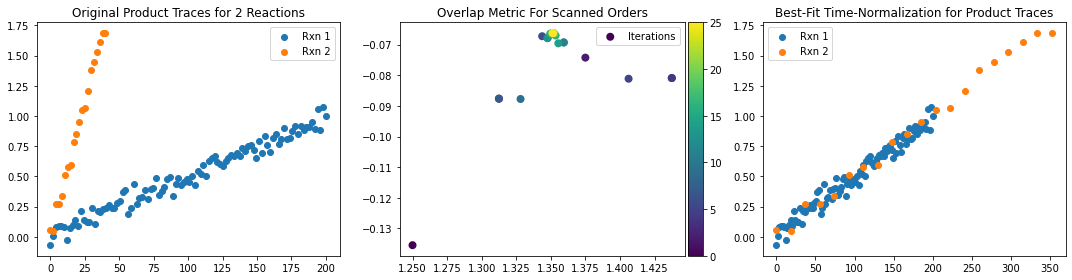

In [271]:
t1 = rxn_traces[cat_concs[0]]['t']
p1 = rxn_traces[cat_concs[0]]['p1']
t2 = rxn_traces[cat_concs[-1]]['t']
p2 = rxn_traces[cat_concs[-1]]['p1']
  
c1 = float(cat_concs[0])
c2 = float(cat_concs[-1])

result, history = order_opt(t1, t2, p1, p2, c1, c2, o_range=(0,2.5), method='Nelder-Mead', metric='RMSD', 
                          to_smooth=False, win1=None, win2=None, window_type='blackman', plot=True, figsize=(15,4))

Best fit achieved for an order of 1.02.


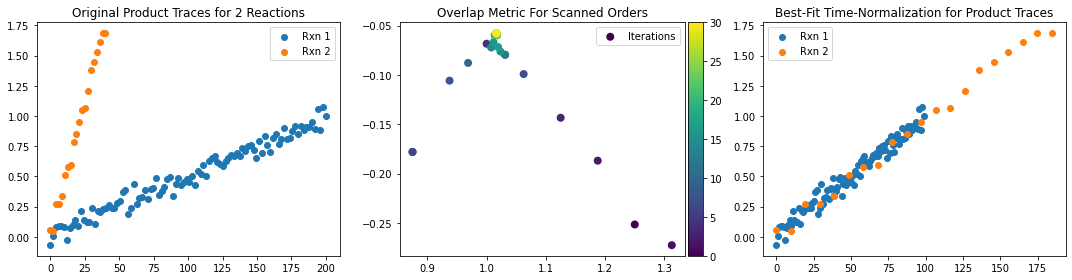

In [270]:
result, history = order_opt(t1, t2, p1, p2, c1-poisoning, c2-poisoning, o_range=(0,2.5), method='Nelder-Mead', metric='RMSD', 
                          to_smooth=False, win1=None, win2=None, window_type='blackman', plot=True, figsize=(15,4))

In [269]:
from pyvtna.signal import get_best_win, smooth

In [272]:
t1 = rxn_traces[cat_concs[0]]['t']
p1 = rxn_traces[cat_concs[0]]['p1']
t2 = rxn_traces[cat_concs[-1]]['t']
p2 = rxn_traces[cat_concs[-1]]['p1']
  
c1 = float(cat_concs[0])
c2 = float(cat_concs[-1])

to_smooth = True
order = 1

overlaps = []
for pois in np.arange(0, 0.8, 0.02):
    p1 = rxn_traces[cat_concs[0]]['p1']
    p2 = rxn_traces[cat_concs[-1]]['p1']
#     fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 4))
#     fig.suptitle(f'Poisoning: {pois}')
    
    win1 = 1
    win2 = 1
#     ax1.scatter(t1, p1, label='r1')
#     ax1.scatter(t2, p2, label='r2')
#     ax1.set_title('Original Traces')
#     ax1.legend()
    if to_smooth:
        p1 = smooth(p1, window_len=win1, window='blackman')
        p2 = smooth(p2, window_len=win2, window='blackman')
#     ax2.scatter(t1, p1, label='r1')
#     ax2.scatter(t2, p2, label='r2')
#     ax2.set_title('Smoothed Traces')
#     ax2.legend()
    t1_norm = normalize_time(t1, c1 - pois, order)
    t2_norm = normalize_time(t2, c2 - pois, order)
#     ax3.scatter(t1_norm, p1, label='r1')
#     ax3.scatter(t2_norm, p2, label='r2')
#     ax3.set_title('Normalized Smoothed Traces')
#     ax3.legend()
    # find the domain of overlap between sig1 and transformed sig2
    min_t = np.max([t1_norm[0], t2_norm[0]])
    max_t = np.min([t1_norm[-1], t2_norm[-1]])
    t1_over = t1_norm[(t1_norm >= min_t) & (t1_norm <= max_t)]
    t2_over = t2_norm[(t2_norm >= min_t) & (t2_norm <= max_t)]
    # f. downsample the higher frequency signal over the overlap range
    #    to match the frequency of the lower frequency signal
    if len(t2_over) > len(t1_over):
        f = interp1d(t2_norm, p2)
        prod2_int = f(t1_over)
        prod1_int = p1[(t1_norm >= min_t) & (t1_norm <= max_t)]
#         ax4.scatter(t1_over, prod1_int, label='r1')
#         ax4.scatter(t1_over, prod2_int, label('r2'))
#         ax4.set_title('Interpolated Normalized Smoothed Traces')
#         ax4.legend()
    else:
        f = interp1d(t1_norm, p1)
        prod1_int = f(t2_over)
        prod2_int = p2[(t2_norm >= min_t) & (t2_norm <= max_t)]
#         ax4.scatter(t2_over, prod1_int, label='r1')
#         ax4.scatter(t2_over, prod2_int, label='r2')
#         ax4.set_title('Interpolated Normalized Smoothed Traces')
#         ax4.legend()
    overlaps.append(metric(prod1_int, prod2_int))
#     plt.tight_layout()
#     plt.show()

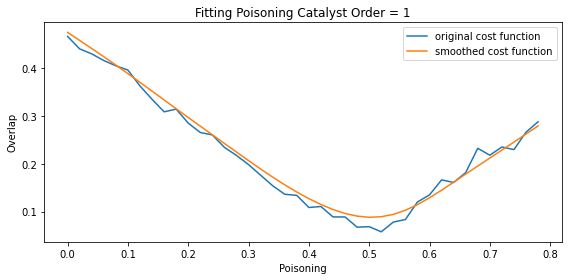

In [280]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
os_sm = smooth(np.array(overlaps), window_len=len(overlaps) // 2, window='blackman')
ax.plot(np.arange(0, 0.8, 0.02), overlaps, label='original cost function')
ax.plot(np.arange(0, 0.8, 0.02), os_sm, label='smoothed cost function')
ax.set_xlabel('Poisoning')
ax.set_ylabel('Overlap')
ax.legend()
ax.set_title('Fitting Poisoning Catalyst Order = 1')
plt.tight_layout()
plt.show()

In [281]:
poisons = np.arange(0, 0.8, 0.02)
poisons[np.argmin(overlaps)], poisons[np.argmin(os_sm)]

(0.52, 0.5)

In [282]:
len(overlaps) // 2

20